<a href="https://colab.research.google.com/github/islombek-cs/Computer-Vision-Labs/blob/main/Week4_Part2_Lab_Webcam_Calib_Stereo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Islombek Abdurakhmanov  
**ID:** 221236  
**Shared Colab Link:** https://colab.research.google.com/drive/1zkI75UMCjLOzkyGeTjlO4A1ZGksBkBSb?usp=sharing


# Lab 4 — Webcam Calibration & Multi‑View Geometry (Colab)

**Module:** Geometric Transformations & Multi‑View Geometry  
**Focus:** Intrinsics calibration (Zhang), Fundamental Matrix, Rectification, Disparity & Depth

> This notebook is designed for **Google Colab** with a **webcam**. It includes a JS capture helper so students can take photos directly in Colab.


In [1]:
import cv2
import numpy as np

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)


OpenCV: 4.12.0
NumPy: 2.0.2


In [2]:
import cv2, numpy as np
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("imread/cvtColor/TERM_CRITERIA_EPS:",
      hasattr(cv2, "imread"), hasattr(cv2, "cvtColor"), hasattr(cv2, "TERM_CRITERIA_EPS"))


OpenCV: 4.12.0
NumPy: 2.0.2
imread/cvtColor/TERM_CRITERIA_EPS: True True True


In [3]:
print("imread:", hasattr(cv2, "imread"),
      "cvtColor:", hasattr(cv2, "cvtColor"),
      "TERM_CRITERIA_EPS:", hasattr(cv2, "TERM_CRITERIA_EPS"))

imread: True cvtColor: True TERM_CRITERIA_EPS: True


In [4]:
# ==== Setup ====


import numpy as np
import matplotlib.pyplot as plt
import os, glob
from skimage import img_as_ubyte
from google.colab import files
from google.colab import output
from IPython.display import display, Javascript
from base64 import b64decode
from google.colab.patches import cv2_imshow

np.set_printoptions(precision=4, suppress=True)
print("Versions -> numpy:", np.__version__)

Versions -> numpy: 2.0.2


In [5]:
import cv2
print(cv2.__version__)
print(hasattr(cv2, "imread"), hasattr(cv2, "cvtColor"), hasattr(cv2, "TERM_CRITERIA_EPS"))


4.12.0
True True True


## Helper — Webcam capture in Colab

In [6]:

def take_photo(filename='frame.jpg', quality=0.8):
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = '📸 Capture';
        div.appendChild(capture);

        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

        await new Promise((resolve) => capture.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop();
        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
      }
    ''')
    display(js)
    data = output.eval_js('takePhoto(%f)' % quality)
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename



---
## Part 1 — Camera Calibration (Zhang) with a Checkerboard


Capture 8–12 images. Vary pose and tilt; ensure the board is fully visible.


<IPython.core.display.Javascript object>

OK: calib_01.jpg


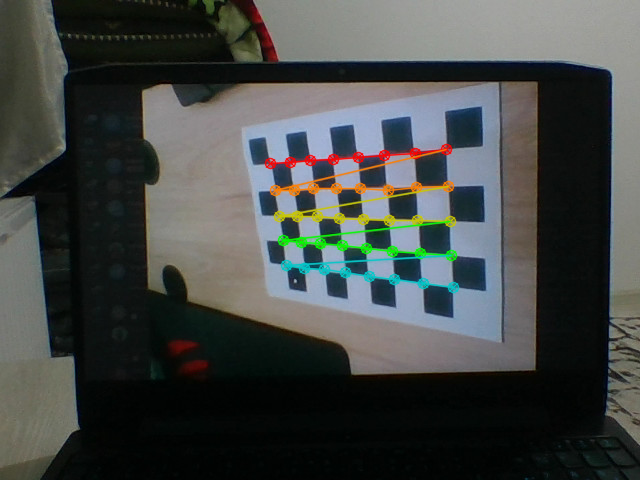

<IPython.core.display.Javascript object>

OK: calib_02.jpg


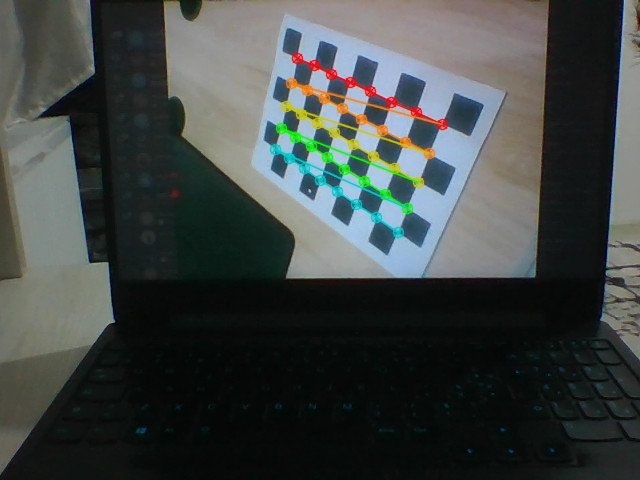

<IPython.core.display.Javascript object>

OK: calib_03.jpg


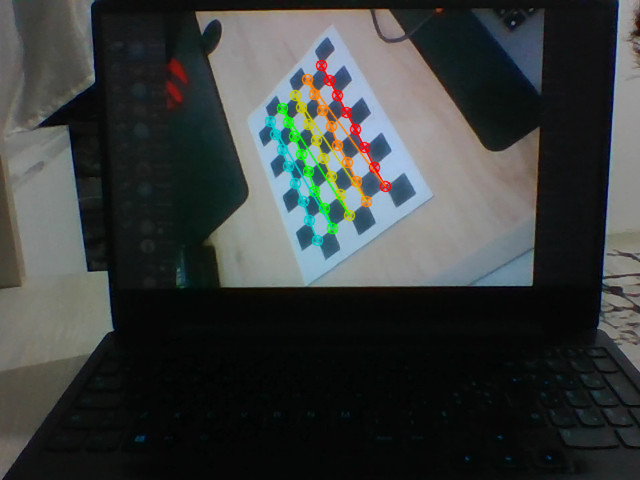

<IPython.core.display.Javascript object>

OK: calib_04.jpg


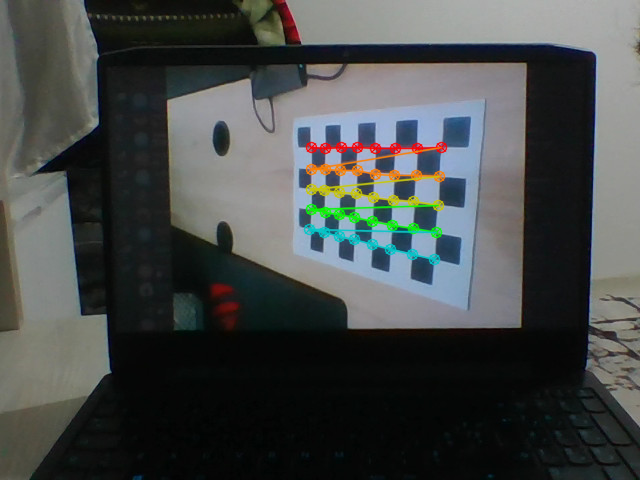

<IPython.core.display.Javascript object>

OK: calib_05.jpg


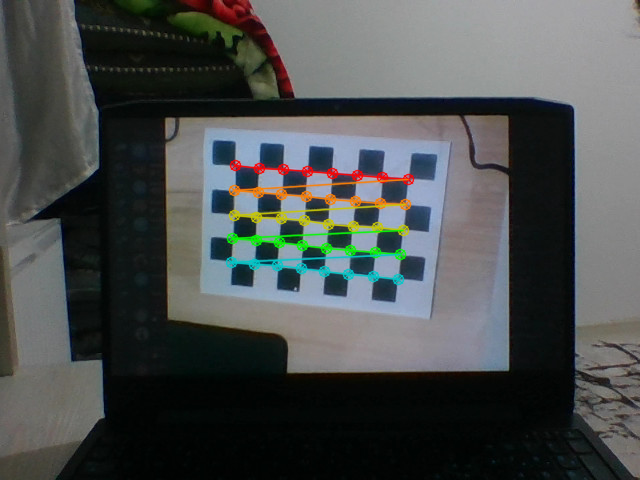

<IPython.core.display.Javascript object>

OK: calib_06.jpg


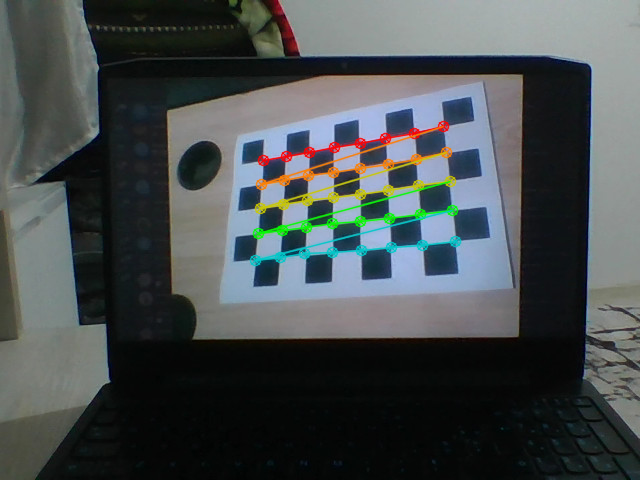

<IPython.core.display.Javascript object>

OK: calib_07.jpg


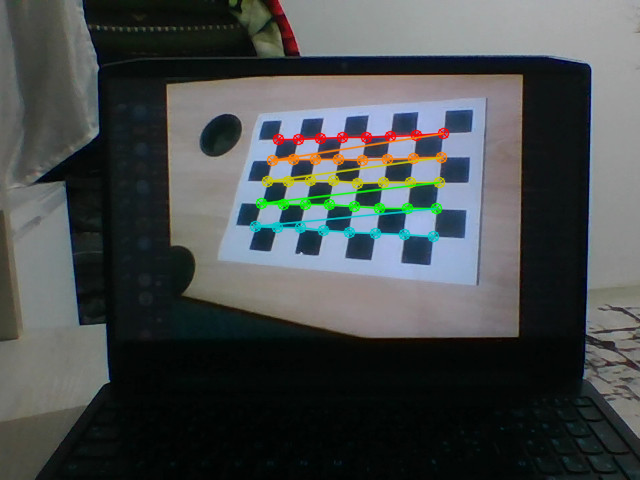

<IPython.core.display.Javascript object>

OK: calib_08.jpg


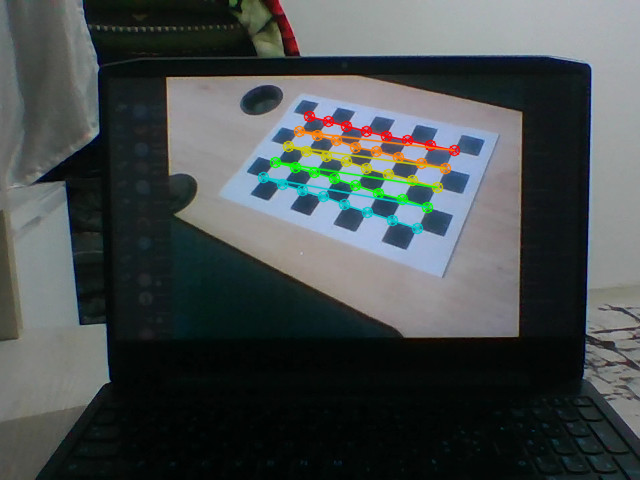

Detected on 8 images.


In [16]:

CHECKERBOARD = (8,5)   # (cols, rows) inner corners
SQUARE_SIZE = 0.03

objp = np.zeros((CHECKERBOARD[0]*CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2) * SQUARE_SIZE


criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

objpoints, imgpoints, captured_paths = [], [], []
print("Capture 8–12 images. Vary pose and tilt; ensure the board is fully visible.")
for i in range(8):
    path = take_photo(f'calib_{i+1:02d}.jpg', quality=0.9)
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)
    disp = img.copy()
    if ret:
        corners2 = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
        cv2.drawChessboardCorners(disp, CHECKERBOARD, corners2, ret)
        objpoints.append(objp.copy())
        imgpoints.append(corners2)
        captured_paths.append(path)
        print(f"OK: {path}")
    else:
        print(f"⚠️ Corners not found: {path}")
    cv2_imshow(disp)

print("Detected on", len(captured_paths), "images.")


In [17]:

assert len(objpoints) >= 5, "Need at least 5 successful captures."
img0 = cv2.imread(captured_paths[0])
h, w = img0.shape[:2]
ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, (w,h), None, None)
print("RMS error:", ret)
print("K (intrinsics):\n", K)
print("Distortion:", dist.ravel())


RMS error: 0.7645255109460438
K (intrinsics):
 [[383.961    0.     347.074 ]
 [  0.     385.6214 209.9772]
 [  0.       0.       1.    ]]
Distortion: [ 0.2278 -3.5917 -0.0082  0.0066 10.4729]


<IPython.core.display.Javascript object>

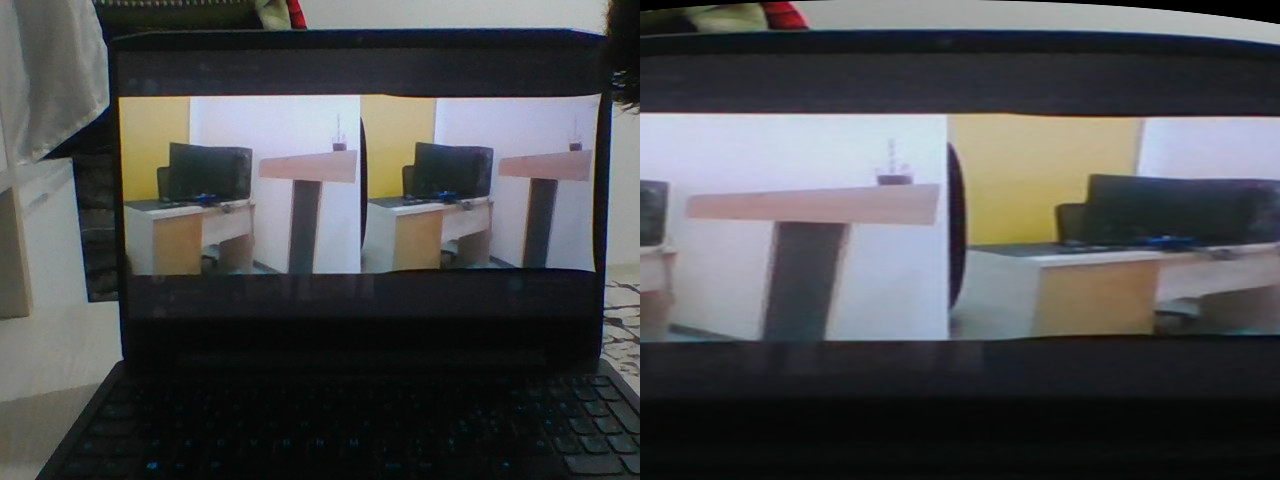

In [18]:

# Undistortion check
path = take_photo('undistort_test.jpg', quality=0.9)
img = cv2.imread(path)
newK, roi = cv2.getOptimalNewCameraMatrix(K, dist, (img.shape[1], img.shape[0]), 1)
und = cv2.undistort(img, K, dist, None, newK)
cv2_imshow(np.hstack([img, und]))



---
## Part 2 — Two Views: Fundamental Matrix & Epipolar Lines


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

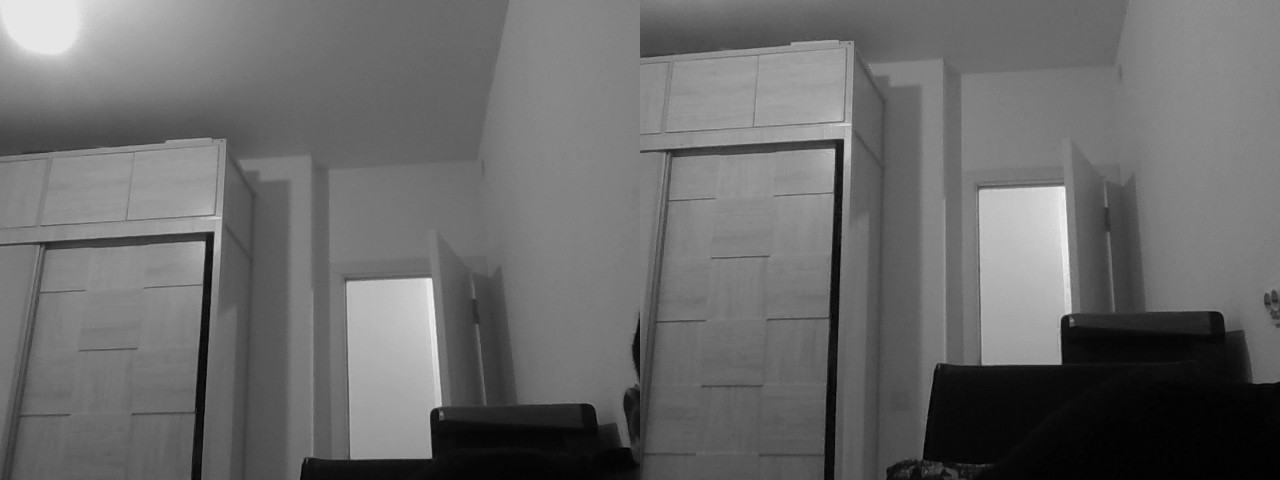

In [19]:

pathL = take_photo('left.jpg', quality=0.9)
pathR = take_photo('right.jpg', quality=0.9)
imgL = cv2.imread(pathL, cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread(pathR, cv2.IMREAD_GRAYSCALE)
cv2_imshow(np.hstack([imgL, imgR]))


In [23]:
# ---------------------------------------------------------
# Part 2 – Fundamental matrix & (optional) Essential matrix
# ---------------------------------------------------------

import cv2
import numpy as np

# 1) Better matching with SIFT + cross-check
def match_pairs(imgL, imgR, ratio=0.75, crosscheck=True):
    sift = cv2.SIFT_create()

    k1, d1 = sift.detectAndCompute(imgL, None)
    k2, d2 = sift.detectAndCompute(imgR, None)

    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    knn = bf.knnMatch(d1, d2, k=2)

    # Lowe's ratio test
    good = [m for m, n in knn if m.distance < ratio * n.distance]

    if crosscheck:
        knn_rev = bf.knnMatch(d2, d1, k=2)
        good_rev = [m for m, n in knn_rev if m.distance < ratio * n.distance]
        set_rev = {(m.trainIdx, m.queryIdx) for m in good_rev}
        good = [m for m in good if (m.queryIdx, m.trainIdx) in set_rev]

    pts1_ = np.float32([k1[m.queryIdx].pt for m in good])
    pts2_ = np.float32([k2[m.trainIdx].pt for m in good])

    return pts1_, pts2_, k1, k2, good


# Run matching first so pts1 / pts2 actually exist
pts1, pts2, k1, k2, good = match_pairs(imgL, imgR, ratio=0.75, crosscheck=True)
print("Matched points:", len(pts1))

# ---------------------------------------------------------
# 0) Optional: undistort points (if you have K, dist from Part 1)
# ---------------------------------------------------------
use_undistort = False   # set True if you want to use K, dist

if use_undistort:
    pts1_ud = cv2.undistortPoints(pts1.reshape(-1, 1, 2), K, dist).reshape(-1, 2)
    pts2_ud = cv2.undistortPoints(pts2.reshape(-1, 1, 2), K, dist).reshape(-1, 2)
    P1, P2 = pts1_ud, pts2_ud
    thr = 0.5   # smaller threshold in normalized coords
else:
    P1, P2 = pts1, pts2
    thr = 1.0   # pixel reprojection threshold


# ---------------------------------------------------------
# 2) Estimate Fundamental matrix F (prefer USAC/MAGSAC if available)
# ---------------------------------------------------------
method = getattr(cv2, "USAC_MAGSAC", cv2.FM_RANSAC)

F, mask = cv2.findFundamentalMat(
    P1, P2,
    method,
    ransacReprojThreshold=thr,
    confidence=0.999,
    maxIters=10000
)

mask = mask.ravel().astype(bool) if mask is not None else np.zeros(len(P1), bool)

print("F:\n", F)
print("Matches:", len(P1), "| Inliers:", mask.sum())


# ---------------------------------------------------------
# 3) Optional: Essential matrix and F-from-E (only makes sense if you calibrated)
# ---------------------------------------------------------
if use_undistort:
    # here pts1 / pts2 are in pixel coords, K is known
    E, mE = cv2.findEssentialMat(
        pts1, pts2, K,
        method=cv2.RANSAC,
        threshold=1.0,
        prob=0.999
    )

    F_from_E = np.linalg.inv(K).T @ E @ np.linalg.inv(K)
    print("Essential matrix E:\n", E)
    print("F derived from E:\n", F_from_E)


Matched points: 33
F:
 [[ 0.      0.     -0.0124]
 [-0.     -0.      0.0083]
 [ 0.0088 -0.0074  0.5593]]
Matches: 33 | Inliers: 32


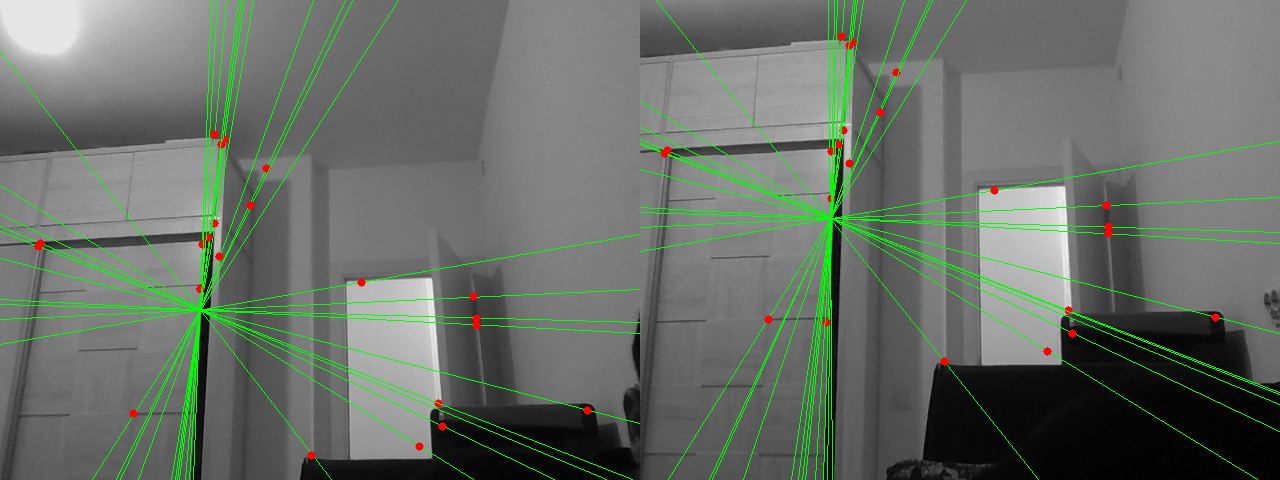

In [24]:

def draw_epilines(img1, img2, F, pts1, pts2, n=25):
    import numpy as np, cv2
    idx = np.random.choice(len(pts1), size=min(n, len(pts1)), replace=False)
    p1 = pts1[idx].reshape(-1,1,2)
    p2 = pts2[idx].reshape(-1,1,2)

    # lines in image 2 for points from image 1 (whichImage=1)
    lines2 = cv2.computeCorrespondEpilines(p1, 1, F).reshape(-1,3)
    img2c = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)
    h2, w2 = img2.shape[:2]
    for r, pt in zip(lines2, p2):
        a,b,c = r
        if abs(b) < 1e-9:
            x = int(-c/a) if abs(a)>1e-9 else 0
            cv2.line(img2c, (x,0), (x,h2-1), (0,255,0), 1)
        else:
            y0 = int(-(c + a*0)/b); y1 = int(-(c + a*(w2-1))/b)
            cv2.line(img2c, (0,y0), (w2-1,y1), (0,255,0), 1)
        cv2.circle(img2c, tuple(np.int32(pt[0])), 4, (0,0,255), -1)

    # lines in image 1 for points from image 2 (whichImage=2)
    lines1 = cv2.computeCorrespondEpilines(p2, 2, F).reshape(-1,3)
    img1c = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
    h1, w1 = img1.shape[:2]
    for r, pt in zip(lines1, p1):
        a,b,c = r
        if abs(b) < 1e-9:
            x = int(-c/a) if abs(a)>1e-9 else 0
            cv2.line(img1c, (x,0), (x,h1-1), (0,255,0), 1)
        else:
            y0 = int(-(c + a*0)/b); y1 = int(-(c + a*(w1-1))/b)
            cv2.line(img1c, (0,y0), (w1-1,y1), (0,255,0), 1)
        cv2.circle(img1c, tuple(np.int32(pt[0])), 4, (0,0,255), -1)
    return img1c, img2c

# Use the SAME domain of points you used for F (raw or undistorted)
img1c, img2c = draw_epilines(imgL, imgR, F, P1[mask], P2[mask])
from google.colab.patches import cv2_imshow
cv2_imshow(np.hstack([img1c, img2c]))



---
## Part 3 — Rectification, Disparity & Depth


E inliers: 29 / 33
recoverPose inliers: 29


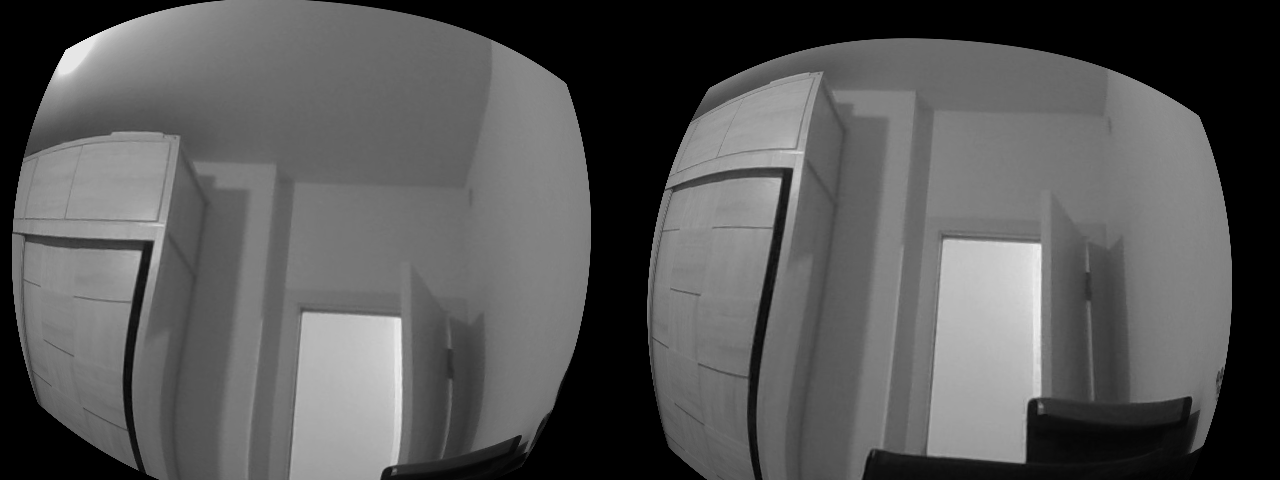

In [25]:

# 0) Sanity: pts1, pts2 are RAW pixel coordinates (same as used to draw on imgL/imgR)
#    K, dist are from your calibration for imgL/imgR frames.

# 1) Estimate Essential directly from raw pixels + K
E, maskE = cv2.findEssentialMat(
    pts1, pts2, K, method=cv2.RANSAC,
    prob=0.999, threshold=1.0, maxIters=10000
)
maskE = maskE.ravel().astype(bool)
print("E inliers:", maskE.sum(), "/", len(pts1))

# 2) Recover relative pose (R, t) from E using the SAME raw points and K
n_inliers, R, t, maskPose = cv2.recoverPose(E, pts1[maskE], pts2[maskE], K)
print("recoverPose inliers:", n_inliers)

# 3) Rectify with the SAME K and dist in BOTH calls
h, w = imgL.shape[:2]
R1, R2, P1, P2, Q, _, _ = cv2.stereoRectify(
    K, dist, K, dist, (w, h), R, t,
    flags=cv2.CALIB_ZERO_DISPARITY, alpha=1.0  # start with 1.0 to avoid cropping-to-black
)

map1x, map1y = cv2.initUndistortRectifyMap(K, dist, R1, P1, (w, h), cv2.CV_32FC1)
map2x, map2y = cv2.initUndistortRectifyMap(K, dist, R2, P2, (w, h), cv2.CV_32FC1)

rectL = cv2.remap(imgL, map1x, map1y, cv2.INTER_LINEAR, borderValue=0)
rectR = cv2.remap(imgR, map2x, map2y, cv2.INTER_LINEAR, borderValue=0)


from google.colab.patches import cv2_imshow
cv2_imshow(np.hstack([rectL, rectR]))



In [26]:
print("map1x range:", np.nanmin(map1x), np.nanmax(map1x), " map1y:", np.nanmin(map1y), np.nanmax(map1y))
print("rectL min/max:", rectL.min(), rectL.max(), " dtype:", rectL.dtype, " shape:", rectL.shape)


map1x range: -921.00757 1804.1178  map1y: -1042.6913 1113.3662
rectL min/max: 0 240  dtype: uint8  shape: (480, 640)


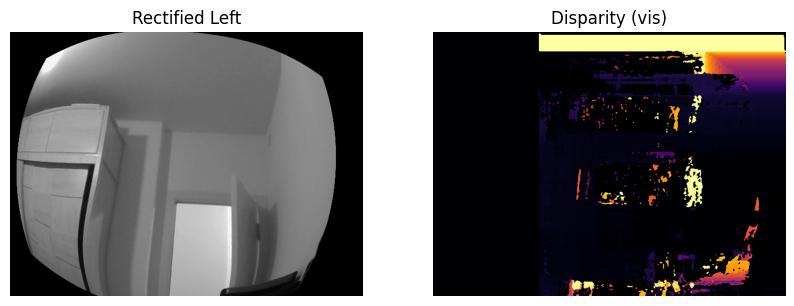

In [27]:

min_disp = 0
num_disp = 16*12
block_size = 5
sgbm = cv2.StereoSGBM_create(
    minDisparity=min_disp,
    numDisparities=num_disp,
    blockSize=block_size,
    P1=8*3*block_size**2,
    P2=32*3*block_size**2,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
)
disp = sgbm.compute(rectL, rectR).astype(np.float32)/16.0
disp_vis = np.clip((disp - min_disp)/num_disp, 0, 1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(rectL, cmap="gray"); plt.title("Rectified Left"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(disp_vis, cmap='inferno'); plt.title("Disparity (vis)"); plt.axis('off')
plt.show()


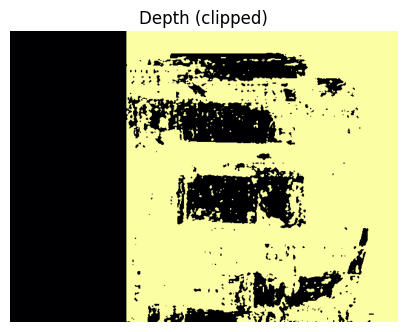

In [28]:

points3D = cv2.reprojectImageTo3D(disp, Q)
Z = points3D[..., 2]
Z_clip = np.clip(Z, 0, np.percentile(Z[Z>0], 0))

plt.figure(figsize=(5,4))
plt.imshow(Z_clip, cmap='inferno'); plt.title("Depth (clipped)"); plt.axis('off'); plt.show()
